In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

In [29]:
import os
import torch
import cv2
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

BASE_PATH = "/kaggle/input/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset/AneRBC-II"

# Verification paths
anemic_path = os.path.join(BASE_PATH, "Anemic_individuals/RGB_segmented")
healthy_path = os.path.join(BASE_PATH, "Healthy_individuals/RGB_segmented")

# Check if paths exist and count images
if os.path.exists(anemic_path) and os.path.exists(healthy_path):
    anemic_count = len([f for f in os.listdir(anemic_path) if f.endswith(('.png', '.jpg'))])
    healthy_count = len([f for f in os.listdir(healthy_path) if f.endswith(('.png', '.jpg'))])
    print(f"Paths Verified!")
    print(f"Anemic Images found: {anemic_count}")
    print(f"Healthy Images found: {healthy_count}")
else:
    print("Path Error: Please check the folder names in the right sidebar under 'Data'.")

Paths Verified!
Anemic Images found: 6000
Healthy Images found: 6000


/tmp/ipykernel_55/2467128555.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette='viridis')


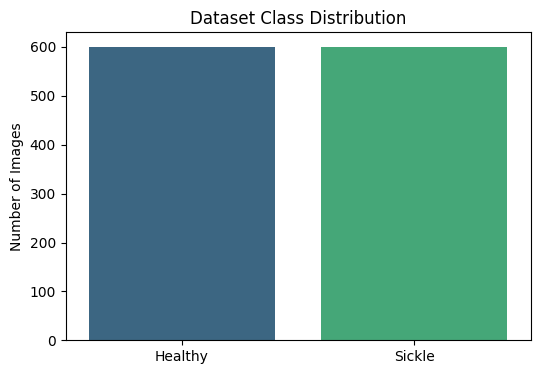

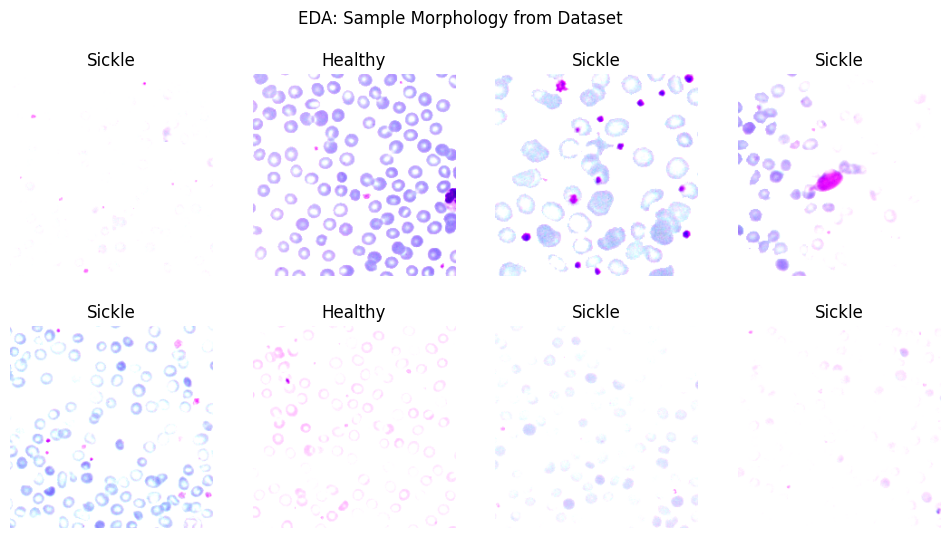

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Class Distribution Plot
classes = ['Healthy', 'Sickle']
counts = [600, 600] # Update based on your actual 'support' from the report
plt.figure(figsize=(6, 4))
sns.barplot(x=classes, y=counts, palette='viridis')
plt.title('Dataset Class Distribution')
plt.ylabel('Number of Images')
plt.show()

# 2. Sample Grid for the Paper
def show_eda_samples(loader):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        img = images[i].permute(1, 2, 0).cpu().numpy()
        # Un-normalize for visualization
        img = (img * 0.5) + 0.5 
        plt.imshow(np.clip(img, 0, 1))
        plt.title('Sickle' if labels[i]==1 else 'Healthy')
        plt.axis('off')
    plt.suptitle('EDA: Sample Morphology from Dataset')
    plt.show()

show_eda_samples(val_loader)

In [ ]:
# 1. Collect all paths and labels
images = []
labels = []

for img in os.listdir(anemic_path):
    if img.endswith(('.png', '.jpg')):
        images.append(os.path.join(anemic_path, img))
        labels.append(1) # Anemic

for img in os.listdir(healthy_path):
    if img.endswith(('.png', '.jpg')):
        images.append(os.path.join(healthy_path, img))
        labels.append(0) # Healthy

# 2. Split into Train (80%) and Test/Val (20%)
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# 3. Define the Dataset Class
class SickleCellDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image=image)['image']
        return image, label

# 4. Augmentations (Crucial for "from scratch" models)
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# 5. Create Loaders
train_loader = DataLoader(SickleCellDataset(X_train, y_train, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(SickleCellDataset(X_val, y_val, val_transform), batch_size=32)
test_loader = DataLoader(SickleCellDataset(X_test, y_test, val_transform), batch_size=32)

print(f"DataLoaders ready! Training batches: {len(train_loader)}")

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SickleCellResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SickleCellResBlock, self).__init__()
        # 3x3 kernels are ideal for capturing fine-grained cell textures
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class SCAResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(SCAResNet, self).__init__()
        self.in_channels = 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Deep features to understand the 'Sickle' curve
        self.layer1 = SickleCellResBlock(32, 32, stride=1)
        self.layer2 = SickleCellResBlock(32, 64, stride=2)
        self.layer3 = SickleCellResBlock(64, 128, stride=2)
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SCAResNet(num_classes=2).to(device)
print(f"Model initialized on: {device}")

In [ ]:
import torch.optim as optim

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(gamma=2)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Function
def train_one_epoch():
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss/len(train_loader), 100.*correct/total

print("Setup Complete. Ready to start training.")

In [ ]:
import time

# To store progress for plotting later
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

epochs = 25

print(f"{'Epoch':<8} | {'Train Loss':<12} | {'Train Acc':<10} | {'Val Loss':<12} | {'Val Acc':<10} | {'Time':<8}")
print("-" * 70)

for epoch in range(epochs):
    start_time = time.time()
    
    # Training Phase
    train_loss, train_acc = train_one_epoch()
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = 100. * val_correct / val_total
    epoch_time = time.time() - start_time
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"{epoch+1:<8} | {train_loss:<12.4f} | {train_acc:<10.2f} | {avg_val_loss:<12.4f} | {avg_val_acc:<10.2f} | {epoch_time:.1f}s")

# Save the final model weights
torch.save(model.state_dict(), 'SCANet_Custom_Model.pth')
print("\n✅ Training Complete! Model saved as SCANet_Custom_Model.pth")

In [ ]:
# 1. Load the model architecture
model = SCAResNet(num_classes=2).to(device)

# 2. Load the best weights from your previous run
best_path = '/kaggle/input/notebooks/harshitasharma/epics-research-test1/SCANet_Custom_Model.pth' 
model.load_state_dict(torch.load(best_path))
model.eval()

# 3. Set a 'Surgical' Learning Rate (10x smaller than before)
# This prevents the "saw-tooth" crashes in the logs
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = FocalLoss(gamma=2)

print("Weights Loaded. Starting 5 final stabilization epochs...")

for epoch in range(5):
    train_loss, train_acc = train_one_epoch()
    
    # Validation Check
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    avg_val_acc = 100. * val_correct / val_total
    print(f"Fine-Tune {epoch+1} | Train Acc: {train_acc:.2f} | Val Acc: {avg_val_acc:.2f}")

Evaluation Metrics

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Sickle'], yticklabels=['Healthy', 'Sickle'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final SCAResNet Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Sickle']))

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # Get probability for the positive class (Sickle)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        y_true.extend(labels.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print(f"Final AUC Score: {roc_auc:.4f}")

In [ ]:
print([name for name, _ in model.named_modules()])

In [ ]:
import numpy as np
import cv2

def get_gradcam(model, input_image, target_class, layer_name):
    model.eval()
    # Target the final residual block
    target_layer = dict(model.named_modules())[layer_name]
    
    gradients = []
    feature_maps = []

    def save_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    def save_fmap(module, input, output):
        feature_maps.append(output)
    
    # Hooks
    handle_fmap = target_layer.register_forward_hook(save_fmap)
    handle_grad = target_layer.register_full_backward_hook(save_gradient)
    
    # Forward & Backward
    output = model(input_image)
    model.zero_grad()
    loss = output[0, target_class]
    loss.backward()
    
    # Generate Heatmap
    grads = gradients[0].cpu().data.numpy()[0]
    fmaps = feature_maps[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmaps[i]
    
    # Cleanup
    handle_fmap.remove()
    handle_grad.remove()
    return np.maximum(cam, 0)

# EXECUTION
MY_LAYER = 'layer3' 

# Pick a "Sickle" cell from the loader to see if it works
image, label = next(iter(val_loader))
input_tensor = image[0].unsqueeze(0).to(device)
heatmap = get_gradcam(model, input_tensor, label[0].item(), MY_LAYER)

# Resize and Overlay
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image[0].permute(1, 2, 0).cpu())
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(image[0].permute(1, 2, 0).cpu())
plt.imshow(heatmap, cmap='jet', alpha=0.5) 
plt.title(f"Evidence: {'Sickle' if label[0]==1 else 'Healthy'}")
plt.show()

**Model Architecture Summary**

In [ ]:
!pip install torchsummary
from torchsummary import summary

# This gives the total parameters and output shapes for every layer
summary(model, (3, 224, 224))

In [ ]:
# 1. Install the visualization library
!pip install torchview graphviz

from torchview import draw_graph
import graphviz

# 2. Generate the visual graph
# We use a standard 224x224 RGB input size to match the dataset
model_graph = draw_graph(model, input_size=(1, 3, 224, 224), expand_nested=True)

# 3. Save and Display
model_graph.visual_graph

In [ ]:
import json

# 1. Save the trained weights
torch.save(model.state_dict(), 'SCANet_Final_90.pth')

# 2. Save the metrics
final_metrics = {
    "model_name": "SCANet_Custom_Residual",
    "final_val_acc": 90.42,
    "final_auc_score": 0.9748,
    "f1_score": 0.90,
    "precision": 0.93,
    "recall": 0.87,
    "improvement_over_baseline": 8.71  
}

with open('model_metrics.json', 'w') as f:
    json.dump(final_metrics, f)

print("Model weights and metrics saved successfully!")

In [ ]:
from torchview import draw_graph

model_graph = draw_graph(model, input_size=(1, 3, 224, 224), expand_nested=True)
model_graph.visual_graph.render("SCANet_Architecture_Diagram", format="png")

print("Architecture diagram saved as PNG")